In [18]:
import stim

import pyzx as zx
import pyzx.simplify as simplify

import random
import math
from fractions import Fraction

In [19]:
class StimToPyZXExtractor:
    SINGLE = {"I": None,
              "X": (zx.utils.VertexType.X, Fraction(1)),
              "Z": (zx.utils.VertexType.Z, Fraction(1)),
              "S": (zx.utils.VertexType.Z, Fraction(1, 2)),
              "S_DAG": (zx.utils.VertexType.Z, Fraction(-1, 2))}
    SINGLE_MULTI = {"H": [(zx.utils.VertexType.H_BOX, None)],
                    "Y": [(zx.utils.VertexType.Z, Fraction(1)), (zx.utils.VertexType.X, Fraction(1))]}
    CNOT_LIKE = {"CX", "CNOT", "ZCX"}
    CZ_LIKE = {"CZ", "ZCZ"}
    MEAS = {"M", "MZ", "MX", "MY"}
    RESET = {"R", "RZ", "RX", "RY"}
    MEAS_RESET = {"MR", "MRZ", "MRX", "MRY"}
    NOOP = {"TICK", "QUBIT_COORDS", "SHIFT_COORDS", "DETECTOR", "OBSERVABLE_INCLUDE"}
    INIT_OPTS = {"open", "zero", "plus"}

    # how a prep spider is colored
    # "state" -> color reflects the prepared state (red = |0>, green = |+>)
    # "match" -> recolor to the nearest spider's color; this FLIPS the represented state (|0><->|+>) on misatched lines
    # "match_keep_state" -> recolour to the nearest spiders color but flip the connecting edge (simple<->Hadamard) so the prepared
    #                       state is unchanged
    PREP_COLORS = {"state", "match", "match_keep_state"}

    def __init__(self, open_inputs = True, max_reps = 1, postselect = True, init = None, prep_color = "state", 
                 serialize_cnot = False, init_all_left = False, avoid_postselection_crossings = False, z_only = False):

        if init is None:
            init = "open" if open_inputs else "zero"
        if init not in self.INIT_OPTS:
            raise ValueError(f"init must be one of {sorted(self.INIT_OPTS)}")
        if prep_color not in self.PREP_COLORS:
            raise ValueError(f"prep_color must be one of {sorted(self.PREP_COLORS)}")
        self.init = init
        self.prep_color = prep_color
        self.open_inputs = init == "open"
        self.max_reps = max_reps
        self.postselect = postselect
        self.serialize_cnot = serialize_cnot
        self.init_all_left = init_all_left
        self.avoid_postselection_crossings = avoid_postselection_crossings
        self.z_only = z_only
        self.init_state(None)
        

    def init_state(self, circuit):
        self.circuit = circuit
        self.n = circuit.num_qubits if circuit is not None else 0
        self.g = zx.graph.Graph()
        self.frontier = {q: None for q in range(self.n)}
        self.pending = {}
        self.inputs = []
        self.outputs = []
        self.meas_qubits = []
        self.mpp_products = []
        self.skipped = {"detector": 0, "observable": 0}
        self.preps = [] 
        
        self._clock = 1
        self._hub_counter = 0

        self.postselection_sites = set()
        self.cnot_target_spiders = set()

    # this is whay i wanted to do in the actual extractor
    # might eaither copy or switch extraction to STIM -> pyZX
    def alloc(self):
        c = self._clock
        self._clock += 1
        return c

    @staticmethod
    def sublayers(items, qubits_of):
        layers = []
        last_layer = {}
    
        for item in items:
            qubits = tuple(qubits_of(item))
            layer_index = 1 + max((last_layer.get(q, -1) for q in qubits), default = -1)
            while len(layers) <= layer_index:
                layers.append([])
            layers[layer_index].append(item)
            for q in qubits:
                last_layer[q] = layer_index
        return layers

    # return True if any CNOT edge at `row` would cross or overlap a post-selection measurement spider
    def postsel_hit(self, pairs, row):
        if not self.avoid_postselection_crossings:
            return False
        for measured_q, measured_row in self.postselection_sites:
            if measured_row != row:
                continue
            for control, target in pairs:
                low = min(control, target)
                high = max(control, target)
                # inclusive so that an overlapping endpoint is also rejected? (edge case maybve)
                if low <= measured_q <= high:
                    return True
    
        return False
    
    # allocate a row for a CNOT group
    # if crossing avoidance is enabled, keep moving right until none of the CNOT edges interacts w/ a post-selectin spider
    def alloc_cnot_row(self, pairs):
        row = self.alloc()
        while self.postsel_hit(pairs, row):
            row = self.alloc()
        return row
        
    def spider(self, q, vtype, phase, col):
        v = self.g.add_vertex(vtype, qubit = q, row = col, phase = phase)
        if self.frontier[q] is not None:
            self.g.add_edge((self.frontier[q], v), zx.utils.EdgeType.SIMPLE)
        self.frontier[q] = v
        return v

    # replace CNOT followed by target <0| with Z-spider fusion
    def absorb_cnot_target_postselection(self, q):
        if not self.z_only:
            return False
    
        target_spider = self.frontier[q]
    
        if target_spider not in self.cnot_target_spiders:
            return False
    
        if self.g.type(target_spider) != zx.utils.VertexType.X:
            return False
    
        self.g.set_type(target_spider, zx.utils.VertexType.Z)
        self.cnot_target_spiders.discard(target_spider)
    
        return True
    
    def prepare_zero_at(self, q, col, hadamard = False):
        v = self.g.add_vertex(zx.utils.VertexType.Z if hadamard else zx.utils.VertexType.X, qubit = q, row = col, phase = Fraction(0))
        self.frontier[q] = v
        self.preps.append(v)

    def ensure_layer(self, involved):
        need = [q for q in involved if self.frontier[q] is None]
        if need:
            c = self.alloc()
            for q in need:
                self.prepare_zero_at(q, c, hadamard = self.pending.pop(q, False))

    def recolor_preps(self):
        if self.prep_color == "state":
            return
        keep = (self.prep_color == "match_keep_state")
        Z, X = zx.utils.VertexType.Z, zx.utils.VertexType.X
        SIMPLE, HAD = zx.utils.EdgeType.SIMPLE, zx.utils.EdgeType.HADAMARD
        for v in self.preps:
            nbrs = list(self.g.neighbors(v))
            if len(nbrs) != 1:
                continue
            w = nbrs[0]
            wt = self.g.type(w)
            if wt not in (Z, X) or self.g.type(v) == wt:
                # neightbour is a boundary (H) or aready matches
                continue              
            self.g.set_type(v, wt)
            if keep:
                e = self.g.edge(v, w)
                et = self.g.edge_type(e)
                self.g.set_edge_type(e, HAD if et == SIMPLE else SIMPLE)

    @staticmethod
    def parse_pauli_products(targets):
        products, current, prev_combiner = [], [], False
        for t in targets:
            if t.is_combiner:
                prev_combiner = True
                continue
            if current and not prev_combiner:
                products.append(current)
                current = []
            if t.is_x_target:
                p = "X"
            elif t.is_y_target:
                p = "Y"
            elif t.is_z_target:
                p = "Z"
            else:
                raise NotImplementedError("MPP target is not a Pauli")
            current.append((t.qubit_value, p, t.is_inverted_result_target))
            prev_combiner = False
        if current:
            products.append(current)
        return products

    def measure_pauli_product(self, product):
        qubits = [q for q, _, _ in product]
        self.ensure_layer(qubits)
        neg = sum(1 for _, _, inv in product if inv) % 2
        hub_phase = Fraction(1) if neg else Fraction(0)
        depth_of = {"Z": 0, "X": 1, "Y": 2}
        depth = max(depth_of[p] for _, p, _ in product)
        pre_cols = [self.alloc() for _ in range(depth)]
        center = self.alloc()
        post_cols = [self.alloc() for _ in range(depth)]
        self.meas_qubits.extend(qubits)
        self.mpp_products.append({"terms": list(product), "inverted": bool(neg)})
        hub_row = self.n
        hub = self.g.add_vertex(zx.utils.VertexType.X, qubit=hub_row, row = center, phase = hub_phase)
        for q, p, _ in product:
            if p == "Z":
                det = self.spider(q, zx.utils.VertexType.Z, Fraction(0), center)
            elif p == "X":
                self.spider(q, zx.utils.VertexType.H_BOX, None, pre_cols[-1])
                det = self.spider(q, zx.utils.VertexType.Z, Fraction(0), center)
                self.spider(q, zx.utils.VertexType.H_BOX, None, post_cols[0])
            else:
                self.spider(q, zx.utils.VertexType.Z, Fraction(-1, 2), pre_cols[-2])
                self.spider(q, zx.utils.VertexType.H_BOX, None, pre_cols[-1])
                det = self.spider(q, zx.utils.VertexType.Z, Fraction(0), center)
                self.spider(q, zx.utils.VertexType.H_BOX, None, post_cols[0])
                self.spider(q, zx.utils.VertexType.Z, Fraction(1, 2), post_cols[1])
            if self.postselect:
                self.postselection_sites.add((q, center))
            self.g.add_edge((det, hub), zx.utils.EdgeType.SIMPLE)
        if not self.postselect:
            col = post_cols[-1] if post_cols else center
            b = self.g.add_vertex(zx.utils.VertexType.BOUNDARY, qubit = hub_row, row = col + 1)
            self.g.add_edge((hub, b), zx.utils.EdgeType.SIMPLE)
            self.outputs.append(b)
        
    def process(self, instrs):
        for inst in instrs:
            if isinstance(inst, stim.CircuitRepeatBlock):
                reps = (inst.repeat_count if self.max_reps is None else min(inst.repeat_count, self.max_reps))
                for _ in range(reps):
                    self.process(inst.body_copy())
                continue
            name = inst.name
            qs = [t.qubit_value for t in inst.targets_copy() if t.is_qubit_target]
            if name in self.NOOP:
                if name == "DETECTOR": self.skipped["detector"] += 1
                if name == "OBSERVABLE_INCLUDE": self.skipped["observable"] += 1
                continue
            if name in self.SINGLE:
                spec = self.SINGLE[name]
                if spec is not None:
                    for grp in self.sublayers(qs, lambda q: (q,)):
                        self.ensure_layer(grp)
                        c = self.alloc()
                        for q in grp:
                            self.spider(q, spec[0], spec[1], c)
            elif name in self.SINGLE_MULTI:
                seq = self.SINGLE_MULTI[name]
                for grp in self.sublayers(qs, lambda q: (q,)):
                    self.ensure_layer(grp)
                    cols = [self.alloc() for _ in seq]
                    for q in grp:
                        for (vt, ph), c in zip(seq, cols):
                            self.spider(q, vt, ph, c)
            elif name in self.CNOT_LIKE:
                pairs = [(qs[i], qs[i + 1]) for i in range(0, len(qs), 2)]
            
                if self.serialize_cnot:
                    groups = [[pair] for pair in pairs]
                else:
                    groups = self.sublayers(pairs, lambda pair: pair)
            
                for grp in groups:
                    c = self.alloc_cnot_row(grp)
            
                    for control, target in grp:
                        target_is_fresh_zero = (self.frontier[target] is None and not self.pending.get(target, False))
                        use_z_unfusion = (self.z_only and target_is_fresh_zero)
            
                        if use_z_unfusion:
                            if self.frontier[control] is None:
                                self.prepare_zero_at(control, c - 1, hadamard = self.pending.pop(control, False))
            
                            self.pending.pop(target, None)
                            z_control = self.spider(control, zx.utils.VertexType.Z, Fraction(0), c)
                            z_target = self.spider(target, zx.utils.VertexType.Z, Fraction(0), c)
            
                            self.g.add_edge((z_control, z_target), zx.utils.EdgeType.SIMPLE)
            
                        else:
                            for q in (control, target):
                                if self.frontier[q] is None:
                                    self.prepare_zero_at(q, c - 1, hadamard=self.pending.pop(q, False))
            
                            z_control = self.spider(control, zx.utils.VertexType.Z, Fraction(0), c)
                            x_target = self.spider(target, zx.utils.VertexType.X, Fraction(0), c)
            
                            self.g.add_edge((z_control, x_target), zx.utils.EdgeType.SIMPLE)
            
                            self.cnot_target_spiders.add(x_target)
            elif name == "SWAP":
                for i in range(0, len(qs), 2):
                    a, b = qs[i], qs[i + 1]
                    self.ensure_layer([a, b])
                    self.frontier[a], self.frontier[b] = self.frontier[b], self.frontier[a]
            elif name == "MPP":
                for prod in self.parse_pauli_products(inst.targets_copy()):
                    self.measure_pauli_product(prod)
            elif name in self.MEAS or name in self.MEAS_RESET:
                if name.endswith("Y"): raise NotImplementedError("Y-basis measure/reset not supported")
                had = name.endswith("X")
                for grp in self.sublayers(qs, lambda q: (q,)):
                    self.ensure_layer(grp)
                    c = None if self.postselect else self.alloc()
                    for q in grp:
                        self.meas_qubits.append(q)
                        if self.postselect:
                            previous = self.frontier[q]
                            if (not had and self.absorb_cnot_target_postselection(q)):
                                absorbed_row = self.g.row(previous)
                                self.postselection_sites.add((q, absorbed_row))
                                self.frontier[q] = None
                                self.pending[q] = False
                                continue
                            col = self.g.row(self.frontier[q]) + 1
                            measurement = self.spider(q, (zx.utils.VertexType.Z if name.endswith("X") else zx.utils.VertexType.X), 
                                                      Fraction(0), col)
                            self.postselection_sites.add((q, col))
                            self.frontier[q] = None
                            self.pending[q] = had  
                        else:
                            b = self.g.add_vertex(zx.utils.VertexType.BOUNDARY, qubit = q, row = c)
                            self.g.add_edge((self.frontier[q], b), zx.utils.EdgeType.HADAMARD if had else zx.utils.EdgeType.SIMPLE)
                            self.outputs.append(b)
                            self.frontier[q] = None
                            if name in self.MEAS_RESET:
                                self.pending[q] = had
            elif name in self.RESET:
                had = name.endswith("X")
                c = None
                for q in qs:
                    if self.frontier[q] is not None:
                        if self.postselect:
                            col = self.g.row(self.frontier[q]) + 1
                            self.spider(q, zx.utils.VertexType.X, Fraction(0), col)
                        else:
                            if c is None: c = self.alloc()
                            b = self.g.add_vertex(zx.utils.VertexType.BOUNDARY, qubit = q, row = c)
                            self.g.add_edge((self.frontier[q], b), zx.utils.EdgeType.SIMPLE)
                            self.outputs.append(b)
                        self.frontier[q] = None
                    self.pending[q] = had
            else:
                raise NotImplementedError(f"gate {name!r} not supported yet")

    def extract(self, circuit):
        if isinstance(circuit, str):
            circuit = stim.Circuit(circuit)
        self.init_state(circuit)
        if self.init == "open":
            c = self.alloc()
            for q in range(self.n):
                b = self.g.add_vertex(zx.utils.VertexType.BOUNDARY, qubit = q, row = c)
                self.inputs.append(b)
                self.frontier[q] = b
        else:
            hadamard = self.init == "plus"
            if self.init_all_left:
                for q in range(self.n):
                    self.prepare_zero_at(q, col = 0, hadamard = hadamard)
            else:
                for q in range(self.n):
                    self.pending[q] = hadamard
        
        self.process(self.circuit)
        live = [q for q in range(self.n) if self.frontier[q] is not None]
        if live:
            c = self.alloc()
            for q in live:
                b = self.g.add_vertex(zx.utils.VertexType.BOUNDARY, qubit = q, row = c)
                self.g.add_edge((self.frontier[q], b), zx.utils.EdgeType.SIMPLE)
                self.outputs.append(b)
        self.recolor_preps()
        self.g.set_inputs(tuple(self.inputs))
        self.g.set_outputs(tuple(self.outputs))
        return self.g, {"measured_qubits": self.meas_qubits, "mpp": self.mpp_products, "skipped": self.skipped}

def stim_to_pyzx(circuit, open_inputs = True, max_reps = 1, postselect = True, init = None, prep_color = "match", 
                 serialize_cnot = True, init_all_left = False, avoid_postselection_crossings = False, z_only = False):
    return StimToPyZXExtractor(open_inputs = open_inputs, max_reps = max_reps, postselect = postselect, 
                               init = init, prep_color = prep_color, serialize_cnot = serialize_cnot, 
                               init_all_left = init_all_left, avoid_postselection_crossings = avoid_postselection_crossings,
                               z_only = z_only).extract(circuit)

In [20]:
def random_MPPs_circuit(n_qubits, depth, seed = None, paulis = "XYZ", products_per_round = (1, 1), p_invert = 0.1, disjoint = True):
    rng = random.Random(seed)
    weight = (1, n_qubits)

    pr_lo, pr_hi = (products_per_round, 
                    products_per_round) if isinstance(products_per_round, int) else (products_per_round[0], products_per_round[1])
    w_lo, w_hi = (weight, weight) if isinstance(weight, int) else (weight[0], weight[1])

    if n_qubits < 1:
        raise ValueError("n_qubits")
    if depth < 0:
        raise ValueError("depth")
    pool = [p for p in paulis if p in paulis]
    if not pool:
        raise ValueError("paulis must contain one of 'X', 'Y', 'Z'")

    lines = []
    for _ in range(depth):
        n_products = rng.randint(pr_lo, pr_hi)
        # print(n_products)
        available = list(range(n_qubits))
        rng.shuffle(available)
        products = []
        for _ in range(n_products):
            w = rng.randint(w_lo, w_hi)
            if disjoint:
                w = min(w, len(available))
                if w == 0:
                    # ran out of fresh qubits 
                    break  
                chosen = [available.pop() for _ in range(w)]
            else:
                w = min(w, n_qubits)
                chosen = rng.sample(range(n_qubits), w)
            terms = [f"{rng.choice(pool)}{q}" for q in chosen]
            product = "*".join(terms)
            if rng.random() < p_invert:
                product = "!" + product
            products.append(product)
        if products:
            lines.append("MPP " + " ".join(products))
    return "\n".join(lines)

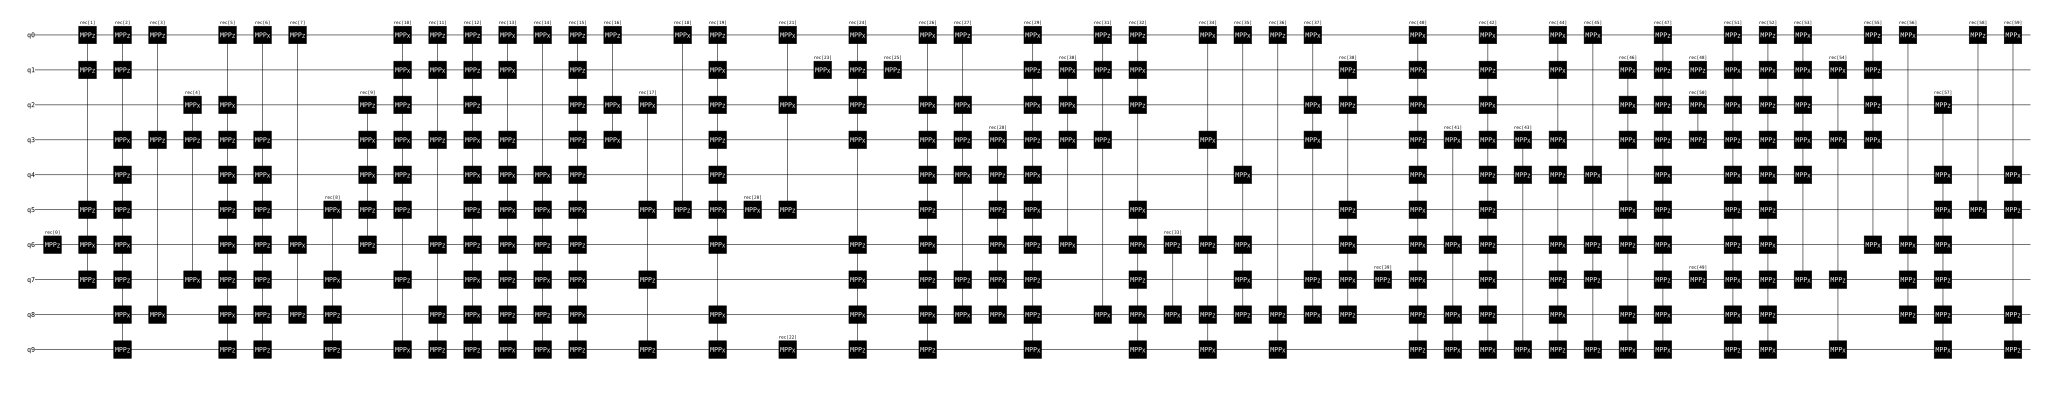

In [21]:
mpp = random_MPPs_circuit(n_qubits = 10, depth = 60, seed = 10, paulis = "XZ")
mpp_g, mpp_info = stim_to_pyzx(mpp, open_inputs = True, postselect = True, serialize_cnot = True, 
                       init_all_left = False, z_only = False, avoid_postselection_crossings = True)
zx.draw(mpp_g)

circuit = stim.Circuit(mpp)
circuit.diagram('timeline-svg')
# print(mpp)

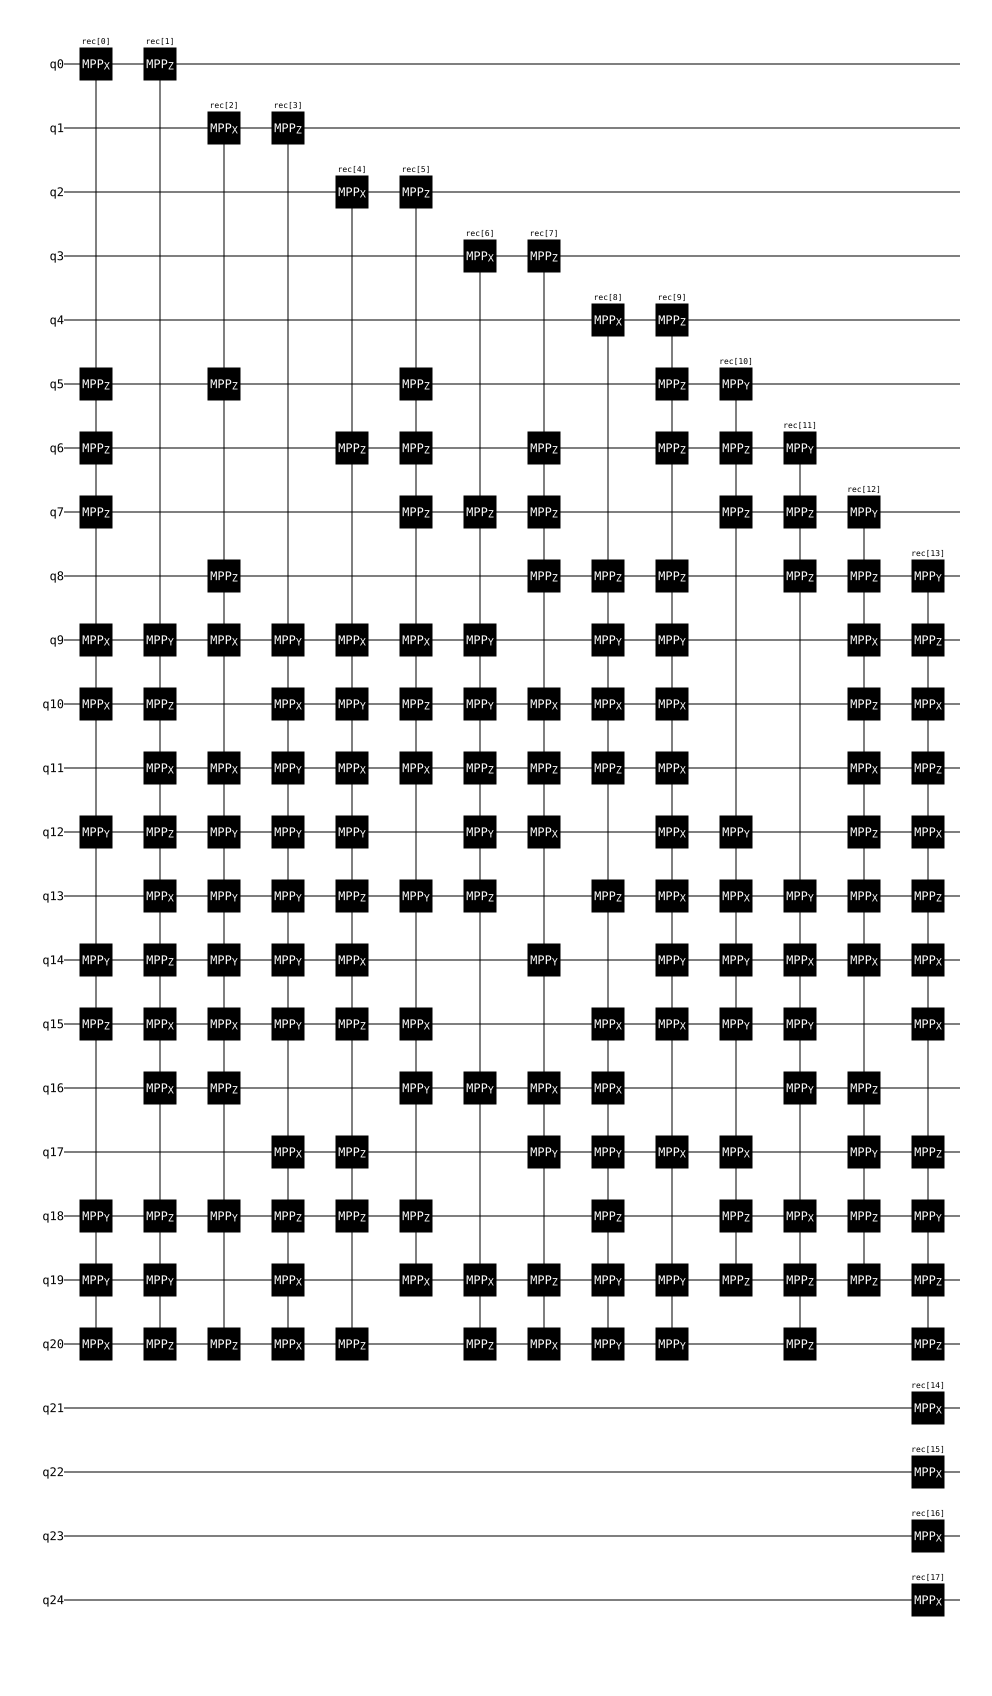

In [24]:
circuit1 = """
MPP X0*Z5*Z6*Z7*X9*X10*Y12*Y14*Z15*Y18*Y19*X20
MPP Z0*Y9*Z10*X11*Z12*X13*Z14*X15*X16*Z18*Y19*Z20
MPP X1*Z5*Z8*X9*X11*Y12*Y13*Y14*X15*Z16*Y18*Z20
MPP Z1*Y9*X10*Y11*Y12*Y13*Y14*Y15*X17*Z18*X19*X20
MPP X2*Z6*X9*Y10*X11*Y12*Z13*X14*Z15*Z17*Z18*Z20
MPP Z2*Z5*Z6*Z7*X9*Z10*X11*Y13*X15*Y16*Z18*X19
MPP X3*Z7*Y9*Y10*Z11*Y12*Z13*Y16*X19*Z20
MPP Z3*Z6*Z7*Z8*X10*Z11*X12*Y14*X16*Y17*Z19*X20
MPP X4*Z8*Y9*X10*Z11*Z13*X15*X16*Y17*Z18*Y19*Y20
MPP Z4*Z5*Z6*Z8*Y9*X10*X11*X12*X13*Y14*X15*X17*Y19*Y20
MPP Y5*Z6*Z7*Y12*X13*Y14*Y15*X17*Z18*Z19
MPP Y6*Z7*Z8*Y13*X14*Y15*Y16*X18*Z19*Z20
MPP Y7*Z8*X9*Z10*X11*Z12*X13*X14*Z16*Y17*Z18*Z19
MPP Y8*Z9*X10*Z11*X12*Z13*X14*X15*Z17*Y18*Z19*Z20
MPP X21
MPP X22
MPP X23
MPP X24
"""
circ = stim.Circuit(circuit1)
circ.diagram('timeline-svg')
# print(info)

In [25]:
g, info = stim_to_pyzx(circuit1, open_inputs = False, postselect = True, serialize_cnot = True, 
                       init_all_left = False, z_only = False, avoid_postselection_crossings = True)
zx.draw(g) 

In [7]:
# import pyzx.simplify as simplify

# # Z GRAPH (fuse -> id) (WITHOUT ALL Z)
# simplify.fuse_simp(g)
# simplify.id_simp(g)
# # CAT STATE (id -> fuse -> id)
# # simplify.fuse_simp(g)
# # simplify.fuse_simp(g)
# # simplify.id_simp(g)
# zx.draw(g)